
===== DATASET SUMMARY =====

--- TRAIN ---
Images: 5196
Label files: 5196
Total objects: 27873
Missing labels: 0
Empty label files: 0
Class distribution:
  bag: 19963
  person: 7910
Image composition:
  only_person: 1200
  bag_and_person: 2382
  only_bag: 1614

--- VAL ---
Images: 649
Label files: 649
Total objects: 3618
Missing labels: 0
Empty label files: 0
Class distribution:
  bag: 2574
  person: 1044
Image composition:
  only_bag: 202
  bag_and_person: 297
  only_person: 150

--- TEST ---
Images: 649
Label files: 649
Total objects: 3784
Missing labels: 0
Empty label files: 0
Class distribution:
  bag: 2824
  person: 960
Image composition:
  only_bag: 203
  bag_and_person: 296
  only_person: 150

--- OVERALL CLASS COUNTS ---
bag: 25361
person: 9914


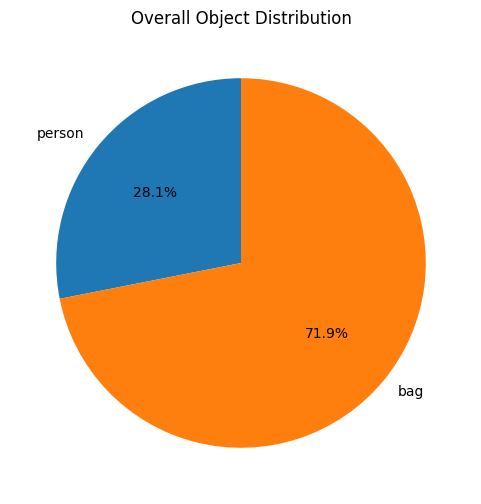

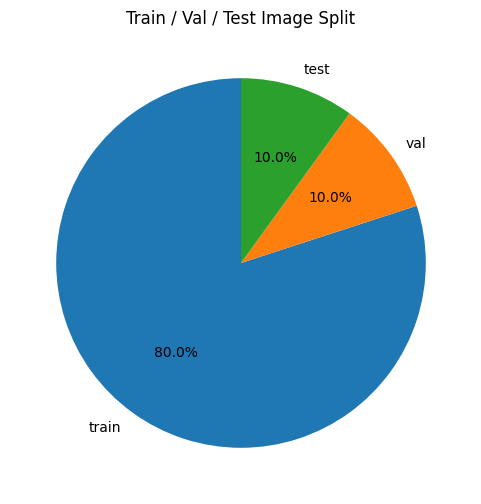

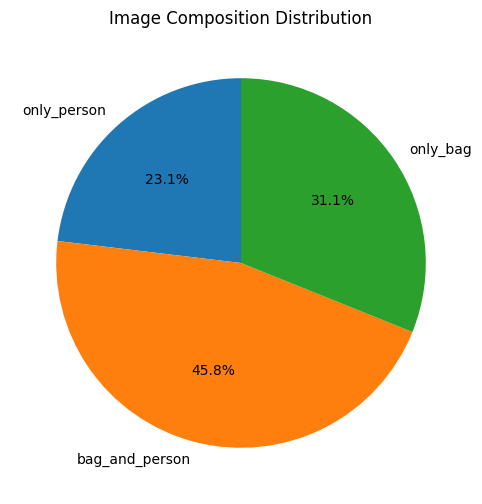

In [ ]:
import os
from collections import defaultdict, Counter
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
DATASET_PATH = "../../data/raw_data/final_dataset"

CLASS_NAMES = {
    0: "bag",
    1: "person"
}

SPLITS = ["train", "val", "test"]


# =========================
# FUNCTION TO ANALYZE ONE SPLIT
# =========================
def analyze_split(images_dir, labels_dir):
    image_files = [
        f for f in os.listdir(images_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    label_files = [
        f for f in os.listdir(labels_dir)
        if f.endswith(".txt")
    ]

    class_counts = defaultdict(int)
    image_type_counter = Counter()

    total_objects = 0
    empty_label_files = 0
    missing_labels = 0

    for img_file in image_files:
        base_name = os.path.splitext(img_file)[0]
        label_path = os.path.join(labels_dir, base_name + ".txt")

        if not os.path.exists(label_path):
            missing_labels += 1
            continue

        with open(label_path, "r") as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]

        if len(lines) == 0:
            empty_label_files += 1
            image_type_counter["empty"] += 1
            continue

        classes_in_image = set()

        for line in lines:
            parts = line.split()
            class_id = int(parts[0])

            class_counts[class_id] += 1
            total_objects += 1
            classes_in_image.add(class_id)

        # classify image content
        if classes_in_image == {0}:
            image_type_counter["only_bag"] += 1
        elif classes_in_image == {1}:
            image_type_counter["only_person"] += 1
        elif classes_in_image == {0, 1}:
            image_type_counter["bag_and_person"] += 1
        else:
            image_type_counter["other"] += 1

    return {
        "num_images": len(image_files),
        "num_label_files": len(label_files),
        "class_counts": dict(class_counts),
        "total_objects": total_objects,
        "empty_label_files": empty_label_files,
        "missing_labels": missing_labels,
        "image_type_counter": dict(image_type_counter),
    }


# =========================
# MAIN
# =========================
split_results = {}
overall_class_counts = defaultdict(int)
overall_image_types = Counter()

for split in SPLITS:
    images_dir = os.path.join(DATASET_PATH, "images", split)
    labels_dir = os.path.join(DATASET_PATH, "labels", split)

    result = analyze_split(images_dir, labels_dir)
    split_results[split] = result

    for cls_id, count in result["class_counts"].items():
        overall_class_counts[cls_id] += count

    overall_image_types.update(result["image_type_counter"])


# =========================
# PRINT SUMMARY
# =========================
print("\n===== DATASET SUMMARY =====")

for split in SPLITS:
    r = split_results[split]
    print(f"\n--- {split.upper()} ---")
    print(f"Images: {r['num_images']}")
    print(f"Label files: {r['num_label_files']}")
    print(f"Total objects: {r['total_objects']}")
    print(f"Missing labels: {r['missing_labels']}")
    print(f"Empty label files: {r['empty_label_files']}")

    print("Class distribution:")
    for cls_id, cls_name in CLASS_NAMES.items():
        print(f"  {cls_name}: {r['class_counts'].get(cls_id, 0)}")

    print("Image composition:")
    for k, v in r["image_type_counter"].items():
        print(f"  {k}: {v}")

print("\n--- OVERALL CLASS COUNTS ---")
for cls_id, cls_name in CLASS_NAMES.items():
    print(f"{cls_name}: {overall_class_counts.get(cls_id, 0)}")


# =========================
# PIE CHART 1: OVERALL OBJECT DISTRIBUTION
# =========================
labels = []
sizes = []

for cls_id, count in overall_class_counts.items():
    labels.append(CLASS_NAMES.get(cls_id, f"class_{cls_id}"))
    sizes.append(count)

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("Overall Object Distribution")
plt.show()


# =========================
# PIE CHART 2: TRAIN/VAL/TEST IMAGE SPLIT
# =========================
split_sizes = [split_results[split]["num_images"] for split in SPLITS]

plt.figure(figsize=(6, 6))
plt.pie(split_sizes, labels=SPLITS, autopct="%1.1f%%", startangle=90)
plt.title("Train / Val / Test Image Split")
plt.show()


# =========================
# PIE CHART 3: IMAGE COMPOSITION
# =========================
comp_labels = list(overall_image_types.keys())
comp_sizes = list(overall_image_types.values())

if len(comp_sizes) > 0:
    plt.figure(figsize=(6, 6))
    plt.pie(comp_sizes, labels=comp_labels, autopct="%1.1f%%", startangle=90)
    plt.title("Image Composition Distribution")
    plt.show()

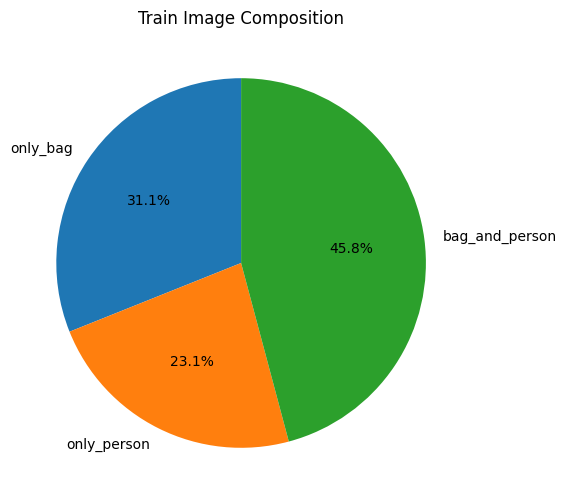

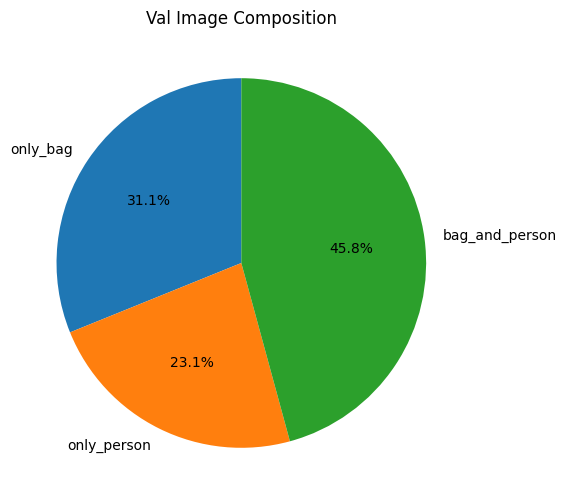

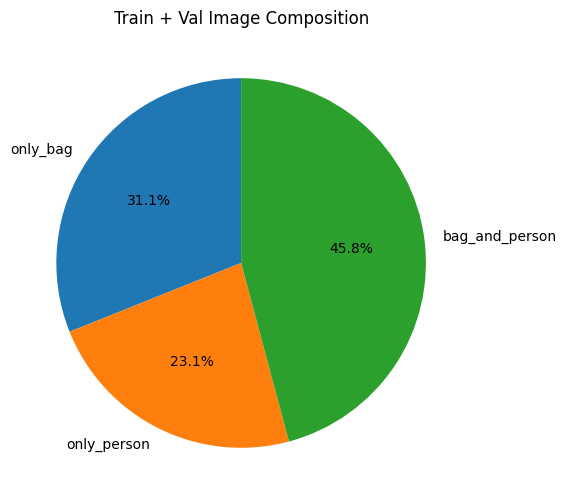

In [3]:
# =========================
# PIE CHART 4: TRAIN IMAGE COMPOSITION
# =========================
train_comp = split_results["train"]["image_type_counter"]

train_labels = ["only_bag", "only_person", "bag_and_person"]
train_sizes = [train_comp.get(label, 0) for label in train_labels]

if sum(train_sizes) > 0:
    plt.figure(figsize=(6, 6))
    plt.pie(train_sizes, labels=train_labels, autopct="%1.1f%%", startangle=90)
    plt.title("Train Image Composition")
    plt.show()


# =========================
# PIE CHART 5: VAL IMAGE COMPOSITION
# =========================
val_comp = split_results["val"]["image_type_counter"]

val_labels = ["only_bag", "only_person", "bag_and_person"]
val_sizes = [val_comp.get(label, 0) for label in val_labels]

if sum(val_sizes) > 0:
    plt.figure(figsize=(6, 6))
    plt.pie(val_sizes, labels=val_labels, autopct="%1.1f%%", startangle=90)
    plt.title("Val Image Composition")
    plt.show()


# =========================
# PIE CHART 6: TRAIN + VAL IMAGE COMPOSITION
# =========================
train_val_comp = Counter()

for label in ["only_bag", "only_person", "bag_and_person"]:
    train_val_comp[label] = (
        split_results["train"]["image_type_counter"].get(label, 0)
        + split_results["val"]["image_type_counter"].get(label, 0)
    )

combined_labels = ["only_bag", "only_person", "bag_and_person"]
combined_sizes = [train_val_comp.get(label, 0) for label in combined_labels]

if sum(combined_sizes) > 0:
    plt.figure(figsize=(6, 6))
    plt.pie(combined_sizes, labels=combined_labels, autopct="%1.1f%%", startangle=90)
    plt.title("Train + Val Image Composition")
    plt.show()


===== TRAIN: BAG + PERSON ONLY =====
Images with both: 2382
bag: 14092
person: 5414


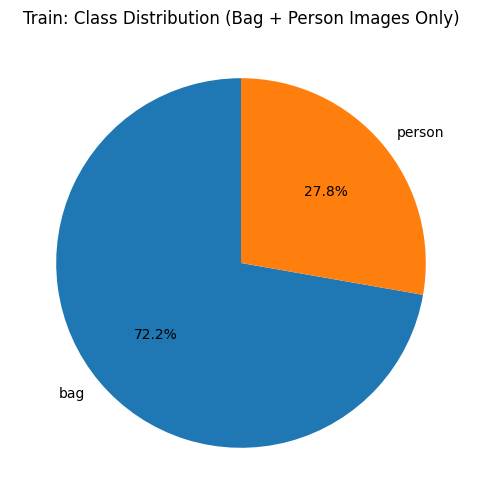

In [7]:
# =========================
# CLASS DISTRIBUTION INSIDE "BAG + PERSON" (TRAIN)
# =========================

train_images_dir = os.path.join(DATASET_PATH, "images", "train")
train_labels_dir = os.path.join(DATASET_PATH, "labels", "train")

bp_class_counts = defaultdict(int)
bp_image_count = 0

for img_file in os.listdir(train_images_dir):
    if not img_file.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    base_name = os.path.splitext(img_file)[0]
    label_path = os.path.join(train_labels_dir, base_name + ".txt")

    if not os.path.exists(label_path):
        continue

    with open(label_path, "r") as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]

    if len(lines) == 0:
        continue

    classes_in_image = set()
    per_image_counts = defaultdict(int)

    for line in lines:
        class_id = int(line.split()[0])
        classes_in_image.add(class_id)
        per_image_counts[class_id] += 1

    # Only keep images with BOTH bag + person
    if classes_in_image == {0, 1}:
        bp_image_count += 1

        for cls_id, count in per_image_counts.items():
            bp_class_counts[cls_id] += count


# =========================
# PRINT RESULTS
# =========================
print("\n===== TRAIN: BAG + PERSON ONLY =====")
print(f"Images with both: {bp_image_count}")

for cls_id, cls_name in CLASS_NAMES.items():
    print(f"{cls_name}: {bp_class_counts.get(cls_id, 0)}")


# =========================
# PIE CHART: BAG vs PERSON (ONLY IN BP IMAGES)
# =========================
labels = [CLASS_NAMES[0], CLASS_NAMES[1]]
sizes = [
    bp_class_counts.get(0, 0),
    bp_class_counts.get(1, 0)
]

if sum(sizes) > 0:
    plt.figure(figsize=(6, 6))
    plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
    plt.title("Train: Class Distribution (Bag + Person Images Only)")
    plt.show()

In [8]:
from ultralytics import YOLO
import cv2
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────────────
WEIGHT_PATH = "../../runs/detect/yolo11m_COCO_V2/exp2/weights/best.pt"
VIDEO_PATH  = "/Users/anbu/Sri/CDS_2026Spring_project/IMG_2163.MOV"       # path to your test footage
OUTPUT_PATH = "./output1.mp4" # where to save the result
CONF        = 0.5
IMGSZ       = 640

# ── Load model ────────────────────────────────────────────────────────────────
model  = YOLO(WEIGHT_PATH)
cap    = cv2.VideoCapture(VIDEO_PATH)

# ── Match output video properties to input ────────────────────────────────────
fps    = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

out = cv2.VideoWriter(
    OUTPUT_PATH,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height),
)

print(f"Processing {total} frames at {fps:.1f} fps...")

# ── Run inference frame by frame ──────────────────────────────────────────────
frame_idx = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results    = model.predict(source=frame, conf=CONF, imgsz=IMGSZ, verbose=False)
    annotated  = results[0].plot()

    out.write(annotated)

    # Progress every 50 frames
    frame_idx += 1
    if frame_idx % 50 == 0:
        print(f"  {frame_idx}/{total} frames done ({frame_idx/total*100:.1f}%)")

cap.release()
out.release()
print(f"\n✅ Saved annotated video → {OUTPUT_PATH}")

Processing 561 frames at 24.0 fps...
  50/561 frames done (8.9%)
  100/561 frames done (17.8%)
  150/561 frames done (26.7%)
  200/561 frames done (35.7%)
  250/561 frames done (44.6%)
  300/561 frames done (53.5%)
  350/561 frames done (62.4%)
  400/561 frames done (71.3%)
  450/561 frames done (80.2%)
  500/561 frames done (89.1%)
  550/561 frames done (98.0%)

✅ Saved annotated video → ./output1.mp4


In [ ]:
'''
Notes & Plans:
Currently the detectionn of bags can be slightly improved. at times the bag detection is at 0.5. 
- can increase the number of bags & person img in dataset where the class distribution of bags is greater than people. 
If no more datasets are available, increase the number of bag only img. 
- Wait to get the training code, see if any changes can be done in it.
- Redo my SAMA COCO model again and check if that can be improved.
- check if combining the datasets can help improve the performance.
'''

'''
Updates:
- running a new model by increasing bags(chagned dataet -> coco1.py and final_dataset) -> did some eda first
- tried merging with SAMA COCO Dataset but realised they were the same images, just reannotated
- played around with the deepsort too -> tried different versions & logic
- Created the base layout for the report and added in the Introduction part. -> check if narative of it is ok?

Next steps:
- Check if the new dataset works, finalise dataset, and update the documentation, refer to the eda.ipynb file for it.
'''

'\nNotes & Plans:\nCurrently the detectionn of bags can be slightly improved. at times the bag detection is at 0.5. \n- can increase the number of bags & person img in dataset where the class distribution of bags is greater than people. \nIf no more datasets are available, increase the number of bag only img. \n- Wait to get the training code, see if any changes can be done in it.\n- Redo my SAMA COCO model again and check if that can be improved.\n- check if combining the datasets can help improve the performance.\n'

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11m.pt")

results = model.train(
    data=r"C:\Users\HP Victus\CDS_2026Spring_project\final_unified_dataset\dataset.yaml",
    epochs=300,
    imgsz=640,
    batch=8,
    device=0,
    workers=4,
    patience=50,
    cache=False,

    project=r"C:\Users\HP Victus\CDS_2026Spring_project\runs\detect\yolo11m_COCO_V2",
    name="exp2",
)

In [2]:
from ultralytics import YOLO
import cv2

# ── Paths ─────────────────────────────────────────────
MODEL_PATH  = "/Users/anbu/Sri/CDS_2026Spring_project/runs/detect/yolo11m_COCO_V2/exp2/weights/best.pt"
VIDEO_PATH  = "/Users/anbu/Sri/CDS_2026Spring_project/video6228796704938794109.mp4"        # your input video
OUTPUT_PATH = "mrtvideo.mp4"       # output video

# ── Load model ────────────────────────────────────────
model = YOLO(MODEL_PATH)

# ── Open video ────────────────────────────────────────
cap = cv2.VideoCapture(VIDEO_PATH)

fps    = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# ── Video writer ──────────────────────────────────────
out = cv2.VideoWriter(
    OUTPUT_PATH,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)

# ── Inference loop ────────────────────────────────────
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Run inference
    results = model(frame, conf=0.4)

    # Draw results
    annotated_frame = results[0].plot()

    # Write frame
    out.write(annotated_frame)

    # Optional: show live
    cv2.imshow("YOLO Detection", annotated_frame)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

# ── Cleanup ───────────────────────────────────────────
cap.release()
out.release()
cv2.destroyAllWindows()

print(f"✅ Saved output to {OUTPUT_PATH}")


0: 384x640 2 persons, 95.9ms
Speed: 1.2ms preprocess, 95.9ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 89.7ms
Speed: 1.1ms preprocess, 89.7ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 95.2ms
Speed: 0.9ms preprocess, 95.2ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 91.6ms
Speed: 0.9ms preprocess, 91.6ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 88.0ms
Speed: 0.8ms preprocess, 88.0ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 87.1ms
Speed: 0.8ms preprocess, 87.1ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 95.2ms
Speed: 0.9ms preprocess, 95.2ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 86.3ms
Speed: 1.0ms preprocess, 86.3ms inference, 0.3ms postprocess per image at shape (

In [6]:
pip install ultralytics opencv-python deep-sort-realtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 21.9 MB/s  0:00:00 eta 0:00:01

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install setuptools==69.5.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 894.6/894.6 kB 32.1 MB/s  0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 82.0.1
    Uninstalling setuptools-82.0.1:
      Successfully uninstalled setuptools-82.0.1

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [13]:
from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort
import cv2

# ── Paths ─────────────────────────────────────────────
MODEL_PATH  = "/Users/anbu/Sri/CDS_2026Spring_project/runs/detect/yolo11m_COCO_V2/exp2/weights/best.pt"
VIDEO_PATH  = "/Users/anbu/Sri/CDS_2026Spring_project/video6228796704938794109.mp4"
OUTPUT_PATH = "output_tracked.mp4"

# ── Load detector ─────────────────────────────────────
model = YOLO(MODEL_PATH)

# ── Init DeepSORT ─────────────────────────────────────
tracker = DeepSort(
    max_age=30,
    n_init=3,
    max_cosine_distance=0.3,
)

# ── Open video ────────────────────────────────────────
cap = cv2.VideoCapture(VIDEO_PATH)

fps    = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(
    OUTPUT_PATH,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)

# class names from your dataset
CLASS_NAMES = {0: "person", 1: "bag"}

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # YOLO inference
    results = model(frame, conf=0.4, classes=[0, 1], verbose=False)
    r = results[0]

    detections_for_tracker = []

    if r.boxes is not None and len(r.boxes) > 0:
        for box in r.boxes:
            cls_id = int(box.cls[0].item())
            conf   = float(box.conf[0].item())
            x1, y1, x2, y2 = box.xyxy[0].tolist()

            w = x2 - x1
            h = y2 - y1

            # DeepSORT expects: ([left, top, width, height], confidence, class_name)
            detections_for_tracker.append((
                [x1, y1, w, h],
                conf,
                CLASS_NAMES.get(cls_id, str(cls_id))
            ))

    # Update tracker
    tracks = tracker.update_tracks(detections_for_tracker, frame=frame)

    # Draw tracks
    for track in tracks:
        if not track.is_confirmed():
            continue

        track_id = track.track_id
        l, t, r_, b = track.to_ltrb()
        cls_name = track.get_det_class() or "obj"

        x1, y1, x2, y2 = map(int, [l, t, r_, b])

        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            frame,
            f"{cls_name}-{track_id}",
            (x1, max(20, y1 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

    out.write(frame)

cap.release()
out.release()
cv2.destroyAllWindows()

print(f"Saved to {OUTPUT_PATH}")

Saved to output_tracked.mp4


In [15]:
from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort
import cv2
from collections import defaultdict

# ── Paths ─────────────────────────────────────────────
MODEL_PATH  = "/Users/anbu/Sri/CDS_2026Spring_project/runs/detect/yolo11m_COCO_V2/exp2/weights/best.pt"
VIDEO_PATH  = "/Users/anbu/Sri/CDS_2026Spring_project/video6228796704938794102.mp4"
OUTPUT_PATH = "output_tracked_simple_logic.mp4"

# ── Config ────────────────────────────────────────────
CONF_THRES = 0.4
SHOW_WINDOW = False

# Tracking stability
TRACK_MAX_AGE = 120              # DeepSORT lost-track tolerance
TRACK_N_INIT = 3
TRACK_MAX_COSINE_DISTANCE = 0.3

# Ownership / state logic
PAIR_IOU_THRES = 0.001           # any tiny overlap counts as "together"
MEMORY_SECONDS = 4.0             # keep association alive this long if one disappears
UNATTENDED_SECONDS = 2.0         # no overlap this long -> unattended
ABANDONED_SECONDS = 5.0          # no overlap this long -> abandoned

# ── Load detector ─────────────────────────────────────
model = YOLO(MODEL_PATH)

# ── Init DeepSORT ─────────────────────────────────────
tracker = DeepSort(
    max_age=TRACK_MAX_AGE,
    n_init=TRACK_N_INIT,
    max_cosine_distance=TRACK_MAX_COSINE_DISTANCE,
)

# ── Open video ────────────────────────────────────────
cap = cv2.VideoCapture(VIDEO_PATH)

fps = cap.get(cv2.CAP_PROP_FPS)
if not fps or fps <= 0:
    fps = 25.0

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(
    OUTPUT_PATH,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)

# class names from your dataset
CLASS_NAMES = {0: "person", 1: "bag"}

# convert seconds to frames
MEMORY_FRAMES = int(MEMORY_SECONDS * fps)
UNATTENDED_FRAMES = int(UNATTENDED_SECONDS * fps)
ABANDONED_FRAMES = int(ABANDONED_SECONDS * fps)

# ── State ─────────────────────────────────────────────
# bag_owner[bag_id] = person_id
bag_owner = {}

# how many consecutive frames bag and owner have had NO overlap
bag_no_overlap_frames = defaultdict(int)

# how many consecutive frames since bag or owner was last seen
bag_missing_frames = defaultdict(int)
owner_missing_frames = defaultdict(int)

# last seen frame for tracks
track_last_seen = {}

# current state text per bag: NORMAL / UNATTENDED / ABANDONED
bag_state = defaultdict(lambda: "NORMAL")


# ── Geometry helpers ──────────────────────────────────
def box_area(box):
    x1, y1, x2, y2 = box
    return max(0.0, x2 - x1) * max(0.0, y2 - y1)

def iou(box_a, box_b):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    iw = max(0.0, ix2 - ix1)
    ih = max(0.0, iy2 - iy1)
    inter = iw * ih

    union = box_area(box_a) + box_area(box_b) - inter
    if union <= 0:
        return 0.0
    return inter / union

def center(box):
    x1, y1, x2, y2 = box
    return ((x1 + x2) / 2.0, (y1 + y2) / 2.0)


# ── Main loop ─────────────────────────────────────────
frame_idx = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_idx += 1

    # YOLO inference
    results = model(frame, conf=CONF_THRES, classes=[0, 1], verbose=False)
    r = results[0]

    detections_for_tracker = []

    if r.boxes is not None and len(r.boxes) > 0:
        for box in r.boxes:
            cls_id = int(box.cls[0].item())
            conf = float(box.conf[0].item())
            x1, y1, x2, y2 = box.xyxy[0].tolist()

            w = x2 - x1
            h = y2 - y1

            detections_for_tracker.append((
                [x1, y1, w, h],
                conf,
                CLASS_NAMES.get(cls_id, str(cls_id))
            ))

    # Update tracker
    tracks = tracker.update_tracks(detections_for_tracker, frame=frame)

    confirmed_people = {}
    confirmed_bags = {}

    # Extract confirmed tracks
    for track in tracks:
        if not track.is_confirmed():
            continue

        track_id = track.track_id
        cls_name = track.get_det_class() or "obj"
        l, t, r_, b = track.to_ltrb()
        box = (float(l), float(t), float(r_), float(b))

        track_last_seen[track_id] = frame_idx

        info = {
            "id": track_id,
            "class": cls_name,
            "box": box,
            "center": center(box),
        }

        if cls_name == "person":
            confirmed_people[track_id] = info
        elif cls_name == "bag":
            confirmed_bags[track_id] = info

    # ── 1) Pair bags to persons using overlap only ───────────────────────────
    # If a bag overlaps any person, tag it to the person with highest overlap.
    for bid, binfo in confirmed_bags.items():
        best_pid = None
        best_iou = 0.0

        for pid, pinfo in confirmed_people.items():
            ov = iou(binfo["box"], pinfo["box"])
            if ov > best_iou:
                best_iou = ov
                best_pid = pid

        if best_pid is not None and best_iou > PAIR_IOU_THRES:
            bag_owner[bid] = best_pid
            bag_no_overlap_frames[bid] = 0
            bag_state[bid] = "NORMAL"

    # ── 2) Update bag states based on owner overlap / memory ─────────────────
    for bid in list(bag_owner.keys()):
        owner_pid = bag_owner[bid]

        bag_present = bid in confirmed_bags
        owner_present = owner_pid in confirmed_people

        # update disappearance counters
        if bag_present:
            bag_missing_frames[bid] = 0
        else:
            bag_missing_frames[bid] += 1

        if owner_present:
            owner_missing_frames[bid] = 0
        else:
            owner_missing_frames[bid] += 1

        # if either bag or owner disappears, keep the pairing for MEMORY_FRAMES
        if not bag_present or not owner_present:
            if bag_missing_frames[bid] > MEMORY_FRAMES or owner_missing_frames[bid] > MEMORY_FRAMES:
                # drop association after memory expires
                del bag_owner[bid]
                bag_no_overlap_frames.pop(bid, None)
                bag_missing_frames.pop(bid, None)
                owner_missing_frames.pop(bid, None)
                bag_state.pop(bid, None)
            continue

        # both are visible -> check overlap
        ov = iou(confirmed_bags[bid]["box"], confirmed_people[owner_pid]["box"])

        if ov > PAIR_IOU_THRES:
            bag_no_overlap_frames[bid] = 0
            bag_state[bid] = "NORMAL"
        else:
            bag_no_overlap_frames[bid] += 1

            if bag_no_overlap_frames[bid] >= ABANDONED_FRAMES:
                bag_state[bid] = "ABANDONED"
            elif bag_no_overlap_frames[bid] >= UNATTENDED_FRAMES:
                bag_state[bid] = "UNATTENDED"
            else:
                bag_state[bid] = "NORMAL"

    # ── 3) Draw persons ───────────────────────────────────────────────────────
    for pid, pinfo in confirmed_people.items():
        x1, y1, x2, y2 = map(int, pinfo["box"])
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            frame,
            f"person-{pid}",
            (x1, max(20, y1 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

    # ── 4) Draw bags with state ───────────────────────────────────────────────
    for bid, binfo in confirmed_bags.items():
        state = bag_state.get(bid, "NORMAL")

        if state == "ABANDONED":
            color = (0, 0, 255)          # red
            label = f"bag-{bid} (abandoned)"
        elif state == "UNATTENDED":
            color = (0, 165, 255)        # orange
            label = f"bag-{bid} (unattended)"
        else:
            color = (255, 200, 0)        # cyan-ish
            label = f"bag-{bid}"

        x1, y1, x2, y2 = map(int, binfo["box"])
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        cv2.putText(
            frame,
            label,
            (x1, max(20, y1 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2
        )

        # optional owner line for currently visible owner
        owner_pid = bag_owner.get(bid)
        if owner_pid is not None and owner_pid in confirmed_people:
            px, py = map(int, confirmed_people[owner_pid]["center"])
            bx, by = map(int, binfo["center"])
            cv2.line(frame, (px, py), (bx, by), (255, 255, 0), 2)

    out.write(frame)

    if SHOW_WINDOW:
        cv2.imshow("Bag-Person Tracking", frame)
        key = cv2.waitKey(1) & 0xFF
        if key == ord("q") or key == 27:
            break

cap.release()
out.release()
cv2.destroyAllWindows()

print(f"Saved to {OUTPUT_PATH}")

Saved to output_tracked_simple_logic.mp4


In [16]:
from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort
import cv2
from collections import defaultdict

# ── Paths ─────────────────────────────────────────────
MODEL_PATH  = "/Users/anbu/Sri/CDS_2026Spring_project/runs/detect/yolo11m_COCO_V2/exp2/weights/best.pt"
VIDEO_PATH  = "/Users/anbu/Sri/CDS_2026Spring_project/video6228796704938794102.mp4"
OUTPUT_PATH = "output_tracked_simple_logic.mp4"

# ── Config ────────────────────────────────────────────
CONF_THRES = 0.55
SHOW_WINDOW = False

# Tracking stability
TRACK_MAX_AGE = 30
TRACK_N_INIT = 4
TRACK_MAX_COSINE_DISTANCE = 0.2

# Ownership / state logic
PAIR_IOU_THRES = 0.001
MEMORY_SECONDS = 2.0           # updated from 4.0 -> 2.0
UNATTENDED_SECONDS = 2.0
ABANDONED_SECONDS = 5.0

# Duplicate suppression for bag tracks
DUPLICATE_BAG_IOU_THRES = 0.7

# ── Load detector ─────────────────────────────────────
model = YOLO(MODEL_PATH)

# ── Init DeepSORT ─────────────────────────────────────
tracker = DeepSort(
    max_age=TRACK_MAX_AGE,
    n_init=TRACK_N_INIT,
    max_cosine_distance=TRACK_MAX_COSINE_DISTANCE,
)

# ── Open video ────────────────────────────────────────
cap = cv2.VideoCapture(VIDEO_PATH)

fps = cap.get(cv2.CAP_PROP_FPS)
if not fps or fps <= 0:
    fps = 25.0

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(
    OUTPUT_PATH,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)

CLASS_NAMES = {0: "person", 1: "bag"}

# Convert seconds to frames
MEMORY_FRAMES = int(MEMORY_SECONDS * fps)
UNATTENDED_FRAMES = int(UNATTENDED_SECONDS * fps)
ABANDONED_FRAMES = int(ABANDONED_SECONDS * fps)

# ── State ─────────────────────────────────────────────
bag_owner = {}                                  # bag_id -> owner person_id
bag_no_overlap_frames = defaultdict(int)        # consecutive no-overlap frames
bag_missing_frames = defaultdict(int)           # consecutive missing frames for bag
owner_missing_frames = defaultdict(int)         # consecutive missing frames for owner (per bag link)
bag_state = defaultdict(lambda: "NORMAL")       # NORMAL / UNATTENDED / ABANDONED


# ── Geometry helpers ──────────────────────────────────
def box_area(box):
    x1, y1, x2, y2 = box
    return max(0.0, x2 - x1) * max(0.0, y2 - y1)

def iou(box_a, box_b):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    iw = max(0.0, ix2 - ix1)
    ih = max(0.0, iy2 - iy1)
    inter = iw * ih

    union = box_area(box_a) + box_area(box_b) - inter
    if union <= 0:
        return 0.0
    return inter / union

def center(box):
    x1, y1, x2, y2 = box
    return ((x1 + x2) / 2.0, (y1 + y2) / 2.0)

def suppress_duplicate_bags(confirmed_bags):
    """
    Removes highly overlapping bag tracks so only one is drawn/used.
    Keeps the first one encountered.
    """
    bag_items = list(confirmed_bags.items())
    kept = {}

    for bid, binfo in bag_items:
        keep = True
        for kept_id, kept_info in kept.items():
            if iou(binfo["box"], kept_info["box"]) > DUPLICATE_BAG_IOU_THRES:
                keep = False
                break
        if keep:
            kept[bid] = binfo

    return kept


# ── Main loop ─────────────────────────────────────────
frame_idx = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_idx += 1

    # YOLO inference
    results = model(frame, conf=CONF_THRES, classes=[0, 1], verbose=False)
    r = results[0]

    detections_for_tracker = []

    if r.boxes is not None and len(r.boxes) > 0:
        for box in r.boxes:
            cls_id = int(box.cls[0].item())
            conf = float(box.conf[0].item())
            x1, y1, x2, y2 = box.xyxy[0].tolist()

            w = x2 - x1
            h = y2 - y1

            # DeepSORT expects: ([left, top, width, height], confidence, class_name)
            detections_for_tracker.append((
                [x1, y1, w, h],
                conf,
                CLASS_NAMES.get(cls_id, str(cls_id))
            ))

    # Update tracker
    tracks = tracker.update_tracks(detections_for_tracker, frame=frame)

    confirmed_people = {}
    confirmed_bags = {}

    # Extract confirmed tracks
    for track in tracks:
        if not track.is_confirmed():
            continue

        track_id = track.track_id
        cls_name = track.get_det_class() or "obj"
        l, t, r_, b = track.to_ltrb()
        box = (float(l), float(t), float(r_), float(b))

        info = {
            "id": track_id,
            "class": cls_name,
            "box": box,
            "center": center(box),
        }

        if cls_name == "person":
            confirmed_people[track_id] = info
        elif cls_name == "bag":
            confirmed_bags[track_id] = info

    # Remove visually duplicated bag tracks
    confirmed_bags = suppress_duplicate_bags(confirmed_bags)

    # ── 1) Pair bags to persons using overlap only ───────────────────────────
    for bid, binfo in confirmed_bags.items():
        best_pid = None
        best_iou = 0.0

        for pid, pinfo in confirmed_people.items():
            ov = iou(binfo["box"], pinfo["box"])
            if ov > best_iou:
                best_iou = ov
                best_pid = pid

        if best_pid is not None and best_iou > PAIR_IOU_THRES:
            bag_owner[bid] = best_pid
            bag_no_overlap_frames[bid] = 0
            bag_state[bid] = "NORMAL"

    # ── 2) Update bag state using owner overlap + memory window ──────────────
    for bid in list(bag_owner.keys()):
        owner_pid = bag_owner[bid]

        bag_present = bid in confirmed_bags
        owner_present = owner_pid in confirmed_people

        # Reset or increment missing counters
        if bag_present:
            bag_missing_frames[bid] = 0
        else:
            bag_missing_frames[bid] += 1

        if owner_present:
            owner_missing_frames[bid] = 0
        else:
            owner_missing_frames[bid] += 1

        # Keep association alive temporarily if either disappears
        if not bag_present or not owner_present:
            if bag_missing_frames[bid] > MEMORY_FRAMES or owner_missing_frames[bid] > MEMORY_FRAMES:
                del bag_owner[bid]
                bag_no_overlap_frames.pop(bid, None)
                bag_missing_frames.pop(bid, None)
                owner_missing_frames.pop(bid, None)
                bag_state.pop(bid, None)
            continue

        # Both visible -> check overlap
        ov = iou(confirmed_bags[bid]["box"], confirmed_people[owner_pid]["box"])

        if ov > PAIR_IOU_THRES:
            bag_no_overlap_frames[bid] = 0
            bag_state[bid] = "NORMAL"
        else:
            bag_no_overlap_frames[bid] += 1

            if bag_no_overlap_frames[bid] >= ABANDONED_FRAMES:
                bag_state[bid] = "ABANDONED"
            elif bag_no_overlap_frames[bid] >= UNATTENDED_FRAMES:
                bag_state[bid] = "UNATTENDED"
            else:
                bag_state[bid] = "NORMAL"

    # ── 3) Draw persons ───────────────────────────────────────────────────────
    for pid, pinfo in confirmed_people.items():
        x1, y1, x2, y2 = map(int, pinfo["box"])
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            frame,
            f"person-{pid}",
            (x1, max(20, y1 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

    # ── 4) Draw bags with state, no owner line ───────────────────────────────
    for bid, binfo in confirmed_bags.items():
        state = bag_state.get(bid, "NORMAL")

        if state == "ABANDONED":
            color = (0, 0, 255)       # red
            label = f"bag-{bid} (abandoned)"
        elif state == "UNATTENDED":
            color = (0, 165, 255)     # orange
            label = f"bag-{bid} (unattended)"
        else:
            color = (255, 200, 0)     # cyan-ish
            label = f"bag-{bid}"

        x1, y1, x2, y2 = map(int, binfo["box"])
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        cv2.putText(
            frame,
            label,
            (x1, max(20, y1 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2
        )

    out.write(frame)

    if SHOW_WINDOW:
        cv2.imshow("Bag-Person Tracking", frame)
        key = cv2.waitKey(1) & 0xFF
        if key == ord("q") or key == 27:
            break

cap.release()
out.release()
cv2.destroyAllWindows()

print(f"Saved to {OUTPUT_PATH}")

Saved to output_tracked_simple_logic.mp4


# Updated model run code

In [2]:
pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.1 MB/s  0:00:00
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.4.21
    Uninstalling ultralytics-8.4.21:
      Successfully uninstalled ultralytics-8.4.21

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")

results = model.train(
    data=r"/Users/anbu/Sri/CDS_2026Spring_project/data/raw_data/final_dataset1/dataset.yaml",
    epochs=300,
    imgsz=640,
    batch=8,
    device= "mps",
    workers=4,
    patience=50,
    cache=False,

    project=r"/Users/anbu/Sri/CDS_2026Spring_project/runs/detect/yolo11m_COCO_V2_1",
    name="exp2",
)

New https://pypi.org/project/ultralytics/8.4.33 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.21 🚀 Python-3.13.7 torch-2.10.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/anbu/Sri/CDS_2026Spring_project/data/raw_data/final_dataset1/dataset.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi

KeyboardInterrupt: 

: 